# InsightEngine: Used Car Price Prediction

## Phase 1: Data Understanding

### Objective

The objective of this phase is to gain a comprehensive understanding of the dataset before performing any preprocessing or model development. This includes examining the dataset's structure, identifying data types, checking for missing and duplicate values, and summarizing the characteristics of each feature.

---

In [11]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Set plotting style
plt.style.use("ggplot")

## Step 1: Load the Dataset

The dataset is loaded from the `data/raw` directory.

In [12]:
# Load the dataset

df = pd.read_csv("../data/raw/car_data.csv")

## Step 2: Display the Dataset

Display the first five records to understand the structure of the dataset.

In [13]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Step 3: Dataset Shape

Determine the number of observations (rows) and features (columns).

In [14]:
print("Dataset Shape:", df.shape)

Dataset Shape: (301, 9)


## Step 4: Column Names

Display all the feature names available in the dataset.

In [15]:
df.columns.tolist()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Kms_Driven',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner']

## Step 5: Dataset Information

Examine data types, number of non-null values, and memory usage.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


## Step 6: Statistical Summary

Generate descriptive statistics for numerical features.

In [17]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Step 7: Statistical Summary Including Categorical Features

In [18]:
df.describe(include="all")

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


## Step 8: Missing Value Analysis

In [19]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [20]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


## Step 9: Duplicate Record Analysis

In [21]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 2


## Step 10: Data Types

In [22]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

## Step 11: Identify Numerical and Categorical Features

Separate the dataset into numerical and categorical features for further analysis.

In [23]:
# Numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_columns)

print("\nCategorical Features:")
print(categorical_columns)

Numerical Features:
['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']

Categorical Features:
['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']


## Step 12: Number of Unique Values

In [24]:
df.nunique()

Car_Name          98
Year              16
Selling_Price    156
Present_Price    147
Kms_Driven       206
Fuel_Type          3
Seller_Type        2
Transmission       2
Owner              3
dtype: int64

## Step 13: Frequency Distribution of Categorical Features

In [25]:
for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Car_Name
Car_Name
city                         26
corolla altis                16
verna                        14
fortuner                     11
brio                         10
ciaz                          9
i20                           9
innova                        9
grand i10                     8
Royal Enfield Classic 350     7
amaze                         7
jazz                          7
eon                           6
sx4                           6
ertiga                        6
swift                         5
alto k10                      5
i10                           5
dzire                         4
Royal Enfield Thunder 350     4
etios liva                    4
wagon r                       4
Bajaj Pulsar 150              4
ritz                          4
Honda CB Hornet 160R          3
Bajaj Avenger 220             3
Yamaha FZ S V 2.0             3
xcent                         3
Bajaj Pulsar NS 200           3
TVS Apache RTR 160            3
etios cross          

## Step 14: Dataset Summary

In [26]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Unique Values
Car_Name,object,0,98
Year,int64,0,16
Selling_Price,float64,0,156
Present_Price,float64,0,147
Kms_Driven,int64,0,206
Fuel_Type,object,0,3
Seller_Type,object,0,2
Transmission,object,0,2
Owner,int64,0,3


## Step 15: Import Visualization Libraries

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

## Step 16: Distribution of Numerical Features

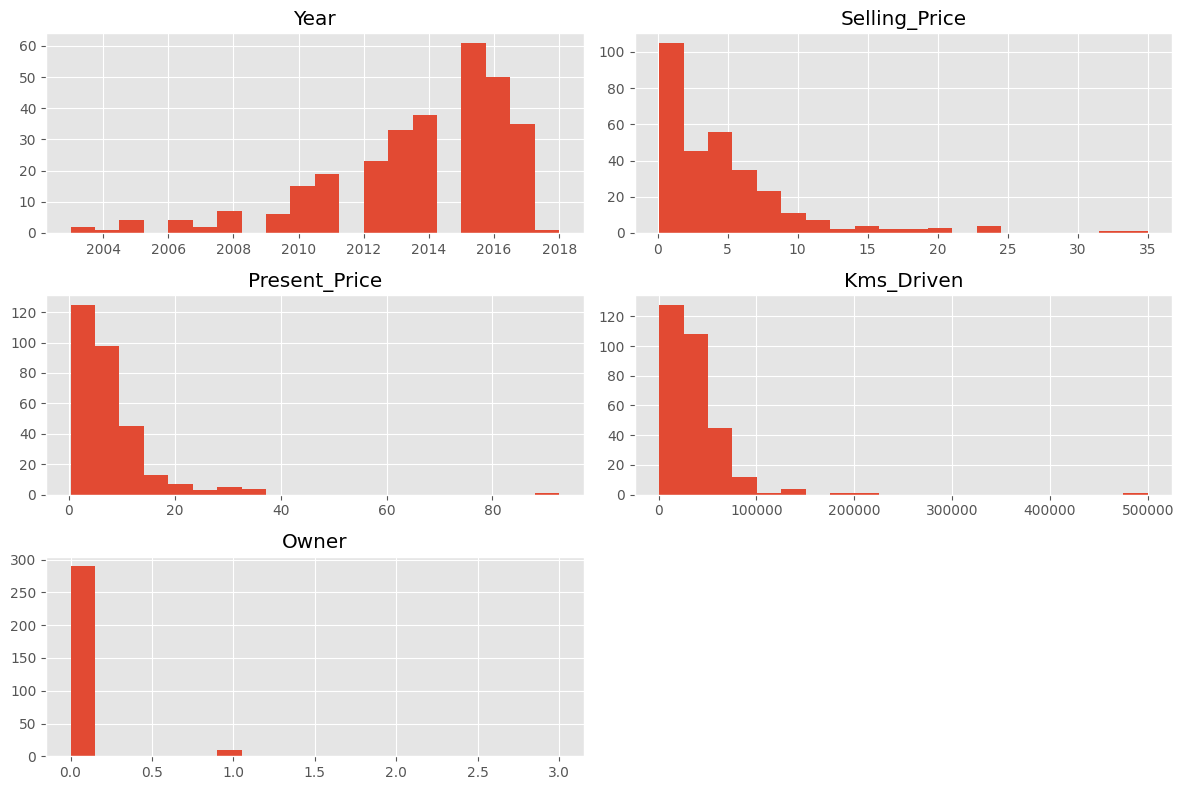

In [28]:
df.hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

## Step 17: Boxplots for Numerical Features

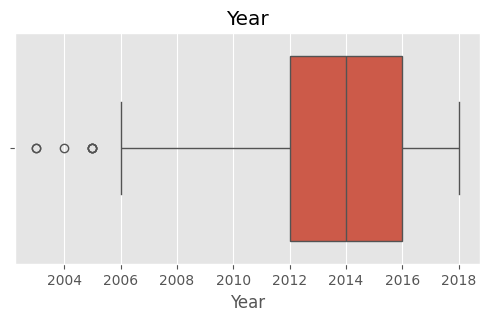

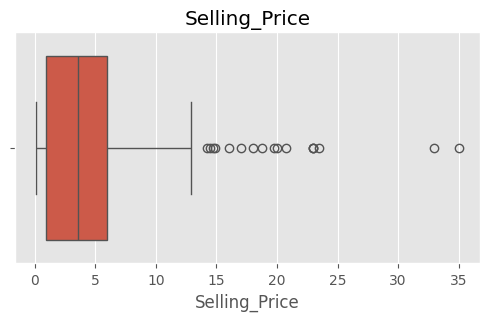

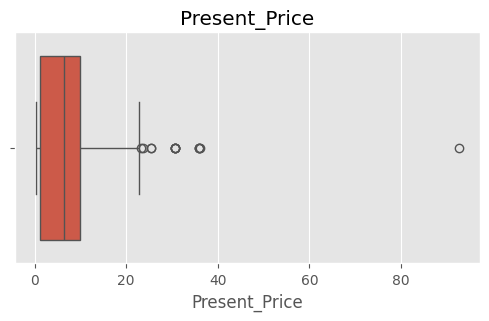

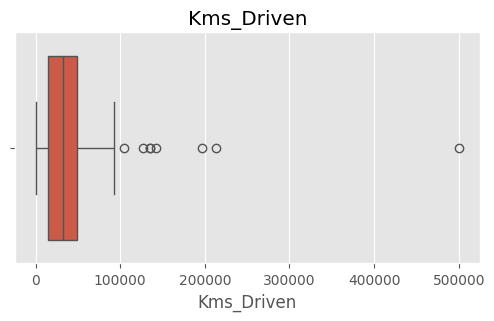

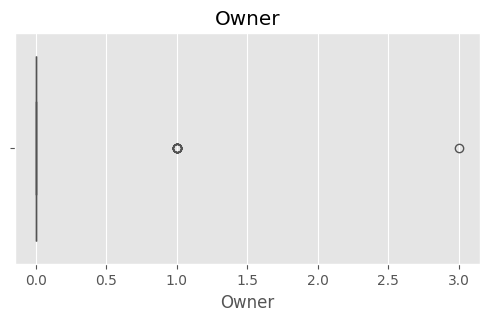

In [29]:
for col in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Step 18: Distribution of Categorical Features

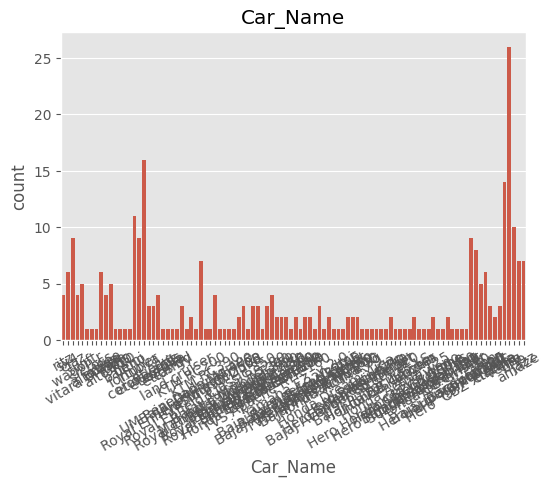

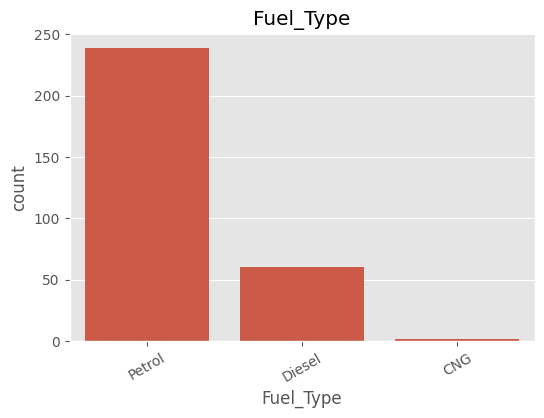

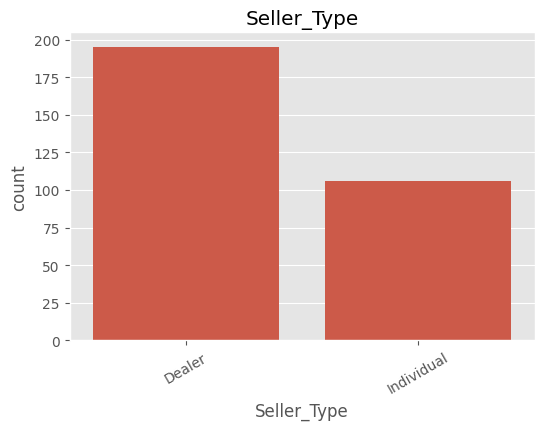

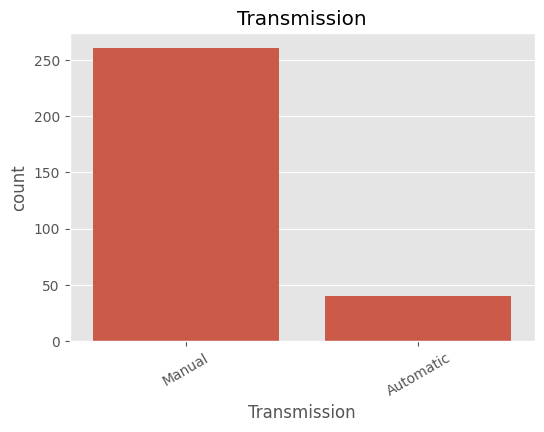

In [30]:
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=30)
    plt.show()

## Step 19: Correlation Matrix

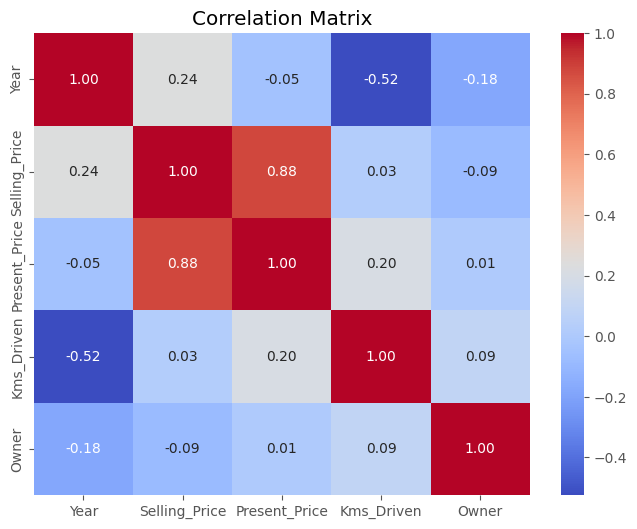

In [31]:
correlation = df[numerical_columns].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Step 20: Relationship Between Numerical Features and Selling Price

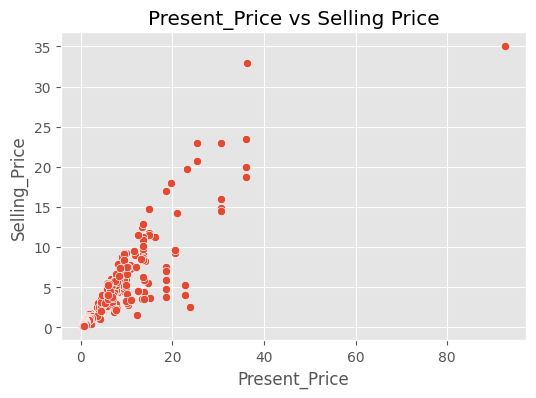

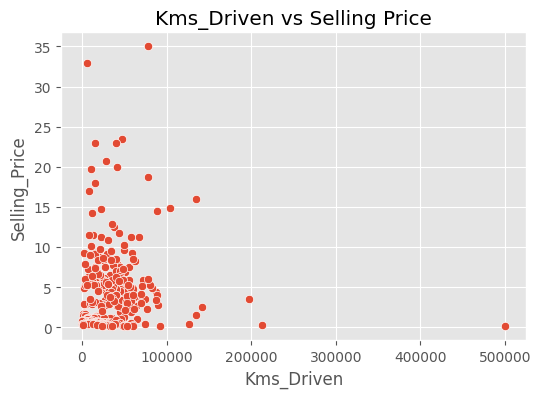

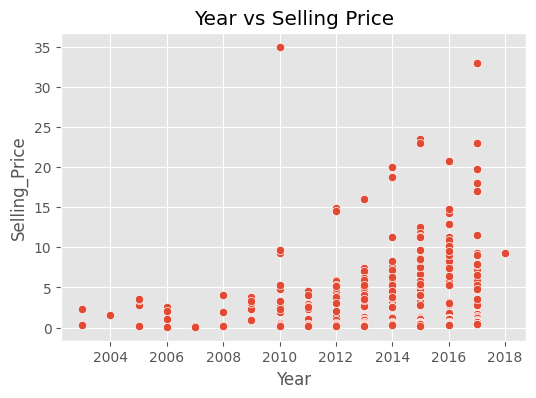

In [32]:
features = ["Present_Price", "Kms_Driven", "Year"]

for col in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col, y="Selling_Price")
    plt.title(f"{col} vs Selling Price")
    plt.show()

# Phase I Observations

- The dataset contains 301 records and 9 features.
- No missing values were found.
- Very few duplicate records are present.
- Selling Price is positively correlated with Present Price.
- Kms_Driven has a weak negative correlation with Selling Price.
- Most vehicles have Manual transmission.
- Petrol cars are more frequent than Diesel and CNG.
- Most cars have a single owner.
- A few numerical features contain outliers.